In [ ]:
# !gdown 10mUC9P8kfHxfc9JCh-CBFE9pIj8lnYIo
# !gdown 1fJf1wesxVRpaCDWN7245xqti1w1MQCEv

/home/clown2/Desktop/Work/Research/wm_cbf
Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}


/home/clown2/anaconda3/envs/wm_cbf/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}


/home/clown2/Desktop/Work/Research/wm_cbf/PytorchReachability/dreamerv3-torch/tools.py:888: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Optimizer model_opt has 27002886 variables.


/home/clown2/anaconda3/envs/wm_cbf/lib/python3.12/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Grid shape: torch.Size([961, 3])
Processing state 960 of 961
Timing has STOPPED.
The timed block took 3.630562 seconds.
Values shape: (31, 31)


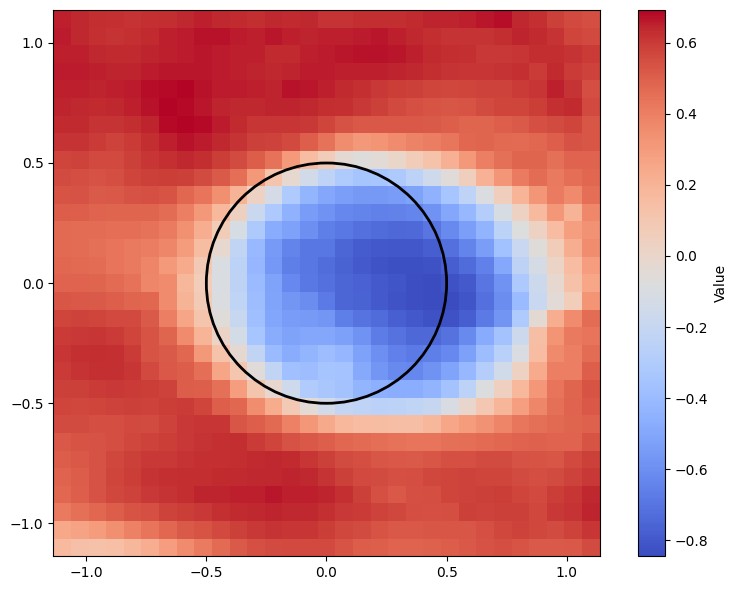

In [ ]:
import os, sys, torch, time
from latent_dubins_ca_wm_pil import LatentDubinContinuousAction

dreamer_dir = 'PytorchReachability/dreamerv3-torch'
sys.path.append(os.path.abspath(dreamer_dir))
import tools, collections 

val_fn = LatentDubinContinuousAction()

# create a grid of data, it should be 3xN, each of the N column should be [x,y,theta], theta is all 0, x and y should fill a grid of 100 x 100 points spanning from val_fn.args.x_min to val_fn.args.x_max and val_fn.args.y_min to val_fn.args.y_max
x_min = -1.1
x_max = 1.1

x = torch.linspace(x_min, x_max, 50)
y = torch.linspace(x_min, x_max, 50)
X, Y = torch.meshgrid(x, y)
grid = torch.stack([X.flatten(), Y.flatten(), torch.pi*torch.ones_like(X.flatten())], dim=1)

print("Grid shape:", grid.shape)

start = time.perf_counter()
values = val_fn.state_to_V(grid[:,:])
end = time.perf_counter()

# Code after the timed block
duration = end - start
print(f"\nTiming has STOPPED.")
print(f"The timed block took {duration:.6f} seconds.")

x_vals = grid[:, 0].reshape(X.shape)
y_vals = grid[:, 1].reshape(Y.shape)
values = values.reshape(X.shape)

print("Values shape:", values.shape)


import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Create the pixelated map
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(x_vals, y_vals, values, cmap='coolwarm')
plt.colorbar(mesh, label='Value')

# Add circle centered at (0,0) with radius 0.5
circle = Circle((0, 0), 0.5, fill=False, edgecolor='black', linestyle='-', linewidth=2)
ax.add_patch(circle)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [4]:
import torch
import numpy as np
from PIL import Image, ImageDraw
import math

def draw_comet(draw, base_center, angle_rad, length, width, fill_color="blue"):
    angle_rad = -angle_rad
    radius = width / 2
    tip_x = base_center[0] + length * math.cos(angle_rad)
    tip_y = base_center[1] + length * math.sin(angle_rad)
    perp_angle = angle_rad + math.pi / 2
    p1_x = base_center[0] + radius * math.cos(perp_angle)
    p1_y = base_center[1] + radius * math.sin(perp_angle)
    p2_x = base_center[0] - radius * math.cos(perp_angle)
    p2_y = base_center[1] - radius * math.sin(perp_angle)
    draw.polygon([(tip_x, tip_y), (p1_x, p1_y), (p2_x, p2_y)], fill=fill_color)
    start_angle_deg = math.degrees(angle_rad) + 90
    end_angle_deg = math.degrees(angle_rad) - 90
    bounding_box = [
        (base_center[0] - radius, base_center[1] - radius),
        (base_center[0] + radius, base_center[1] + radius)
    ]
    draw.pieslice(bounding_box, start=start_angle_deg, end=end_angle_deg, fill=fill_color)


def state_to_image_pil_hq(s, args):
    """
    Generates a high-quality, anti-aliased image from a state.
    """
    # ✅ 1. Use a scale factor for anti-aliasing
    scale = 4
    size = args.size
    h_size = (size[0] * scale, size[1] * scale)
    
    img = Image.new('RGB', h_size, 'white')
    draw = ImageDraw.Draw(img)

    def to_pixel(coord):
        x, y = coord
        # We now map to the high-resolution canvas
        px = int((x + 1.1) / 2.2 * h_size[0])
        py = int((-y + 1.1) / 2.2 * h_size[1])
        return (px, py)

    # --- Draw the circle ---
    center_px = to_pixel((0.0, 0.0))
    radius_px = (args.obs_r / 2.2) * h_size[0]
    draw.ellipse(
        [(center_px[0] - radius_px, center_px[1] - radius_px),
         (center_px[0] + radius_px, center_px[1] + radius_px)],
        outline='red',
        width=2 * scale  # ✅ Use a thin line, scaled up
    )

    # --- Draw the arrow ---
    agent_pos_world = (s[0].item(), s[1].item())
    agent_pos_pixel = to_pixel(agent_pos_world)
    agent_angle_rad = s[2].item()
    
    # Use the comet function, but with scaled length and width
    draw_comet(draw,
               base_center=agent_pos_pixel,
               angle_rad=agent_angle_rad,
               length=17.5 * scale,  # ✅ Scale the comet size
               width=10 * scale,
               fill_color='blue')

    # ✅ 2. Resize the image down to the original size with a high-quality filter
    img = img.resize(size, Image.Resampling.LANCZOS)

    return np.array(img)

# --- Standalone Example Usage ---

s = torch.tensor([0.0, 0.0, np.pi /4])
args = val_fn.args # Assuming args is an attribute of your model

# Generate and save the image
img_array = state_to_image_pil_hq(s, args)
img = Image.fromarray(img_array)
img.save("output_image_with_arrow.png")

print("Image successfully saved as output_image_with_arrow.png")

Image successfully saved as output_image_with_arrow.png


In [4]:
import os, sys, torch
from latent_dubins_ca_wm import LatentDubinContinuousAction

dreamer_dir = 'PytorchReachability/dreamerv3-torch'
sys.path.append(os.path.abspath(dreamer_dir))
import tools, collections 

val_fn = LatentDubinContinuousAction()

# create a grid of data, it should be 3xN, each of the N column should be [x,y,theta], theta is all 0, x and y should fill a grid of 100 x 100 points spanning from val_fn.args.x_min to val_fn.args.x_max and val_fn.args.y_min to val_fn.args.y_max
x_min = -1.1
x_max = 1.1

x = torch.linspace(x_min, x_max, 31)
y = torch.linspace(x_min, x_max, 31)
X, Y = torch.meshgrid(x, y)
grid = torch.stack([X.flatten(), Y.flatten(), torch.pi*torch.ones_like(X.flatten())], dim=1)

print("Grid shape:", grid.shape)

grid = grid[450,:].unsqueeze(0)  # Ensure grid is 2D with shape (1, 3)

values = val_fn.state_to_V(grid[:,:])



/home/clown2/anaconda3/envs/wm_cbf/lib/python3.12/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}
Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}


/home/clown2/Desktop/Work/Research/wm_cbf/PytorchReachability/dreamerv3-torch/tools.py:888: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Optimizer model_opt has 27002886 variables.
Grid shape: torch.Size([961, 3])
